# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ - Majorana - Open boundary conditions tripartite Schmidt decomposition

Created: 21-07-2026

Objectives:
* Apply methods from [this notebook](z2_f_x_z2_t_obc_tripartite_schmidt_decomposition.ipynb) to Majorana states.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
from functools import reduce
from operator import mul

from itertools import product

In [12]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_triv_to_nontriv_n1_10_site_ed_obc"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_10_site_ed_obc"

# Import states

In [13]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]

In [14]:
triv_energies = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

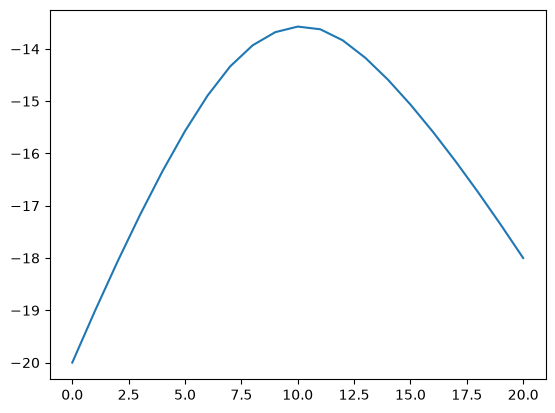

In [15]:
plt.plot(triv_energies)

In [16]:
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi'][:, 0]
    for i in range(0, 101, 5)
]

In [17]:
nontriv_groundstates[0].shape

(1048576,)

In [18]:
nontriv_energies = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

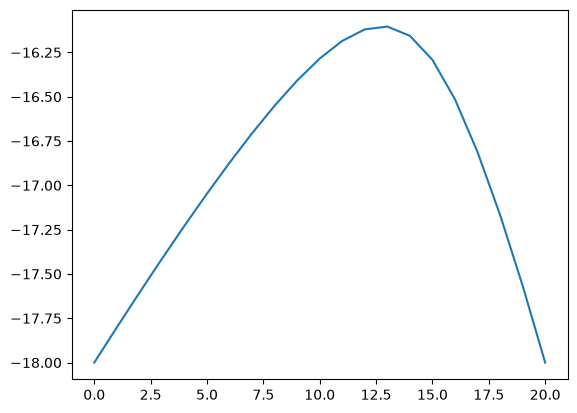

In [19]:
plt.plot(nontriv_energies)

# Definitions

In [20]:
L = 10

In [21]:
spin_basis = spin_basis_1d(L, pauli=-1)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [22]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [23]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [24]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [25]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [26]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [27]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [28]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [29]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [30]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [31]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [32]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [33]:
def get_defect_ops_and_indices_from_rho_tilde(
    qt_rho, rho_tilde, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

# Test reconstruction of $\rho$

## Via expectation values

In [34]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [35]:
psi = triv_groundstates[0]

In [36]:
# Keys: output, input

spin_basis_ops = {
    (0,0): [('z', 0.5), ('I', 0.5)],
    (1,1): [('z', -0.5), ('I', 0.5)],
    (1,0): [('x', 0.5), ('y', 0.5j)],
    (0,1): [('x', 0.5), ('y', -0.5j)],
}

fermion_basis_ops = {
    (0,0): [('I', 1), ('n', -1)],
    (1,1): [('n', 1)],
    (1,0): [('+', 1)],
    (0,1): [('-', 1)],
}

In [37]:
basis_ops = {
    0: spin_basis_ops,
    1: fermion_basis_ops
}

In [38]:
num_symmetry_sites = len(domains_dict['symmetry_sites'])

data = np.zeros((2,)*(2*num_symmetry_sites), dtype=complex)

In [39]:
index_k = (0,)*num_symmetry_sites
index_b = (0,)*num_symmetry_sites

triples = zip(domains_dict['symmetry_sites'], index_k, index_b)

spin_op_pairs = list()
fermion_op_pairs = list()

for site_index, i_k, i_b in triples:
    #spin site
    if site_index%2 == 0:
        spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
    #fermion site
    else:
        fermion_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))

In [40]:
spin_op_pairs

[(8, [('z', 0.5), ('I', 0.5)]),
 (10, [('z', 0.5), ('I', 0.5)]),
 (12, [('z', 0.5), ('I', 0.5)])]

In [41]:
fermion_op_pairs

[(9, [('z', 0.5), ('I', 0.5)]), (11, [('z', 0.5), ('I', 0.5)])]

In [42]:
def get_expectation_from_op_pair_lists(spin_op_pairs, fermion_op_pairs, psi,
                                       basis):
    #Shift specifies wether the first index is a spin (0) or a fermion (1)
    spin_indices, spin_ops = zip(*spin_op_pairs) if spin_op_pairs else ((), ())
    spin_op_combinations = list(product(*spin_ops))
    quspin_spin_indices = [i//2 for i in spin_indices]

    ferm_indices, ferm_ops = zip(*fermion_op_pairs) if fermion_op_pairs else ((), ())
    ferm_op_combinations = list(product(*ferm_ops))
    quspin_ferm_indices = [(i-1)//2 for i in ferm_indices] 

    terms = list()

    for spin_pairs_list in spin_op_combinations:
        spin_ops, spin_strengths = zip(*spin_pairs_list) if spin_pairs_list else ((), ())
        for ferm_pairs_list in ferm_op_combinations:
            ferm_ops, ferm_strengths = zip(*ferm_pairs_list) if ferm_pairs_list else ((), ())

            op_string = ''.join(spin_ops) + '|' + ''.join(ferm_ops)
            op_strength = reduce(mul, spin_strengths + ferm_strengths, 1)

            terms.append([op_string, [[op_strength, *quspin_spin_indices, *quspin_ferm_indices]]])

    op = hamiltonian(
        terms,
        [],
        basis=basis,
        check_herm=False,
        check_symm=False,
    )

    exp = op.expt_value(psi)

    return exp

In [43]:
get_expectation_from_op_pair_lists(
    spin_op_pairs,
    fermion_op_pairs,
    psi,
    basis
)

/tmp/ipykernel_4133/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(


np.complex128(0.06250000000000011+1.6704779438076223e-52j)

In [44]:
def get_fermionic_rho(quspin_psi, domains_dict, verbose=False):
    L = domains_dict['num_system_sites']//2

    spin_basis = spin_basis_1d(L, pauli=-1)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    num_symmetry_sites = len(domains_dict['symmetry_sites'])
    
    data = np.zeros((2,)*(2*num_symmetry_sites), dtype=complex)

    all_k_indices = product(range(2), repeat=num_symmetry_sites)
    all_k_b_indices = list(product(all_k_indices, repeat=2))

    index_iter = tqdm(all_k_b_indices) if verbose else all_k_b_indices

    for index_k, index_b in index_iter:
        triples = zip(domains_dict['symmetry_sites'], index_k, index_b)

        spin_op_pairs = list()
        fermion_op_pairs = list()

        for site_index, i_k, i_b in triples:
            #spin site
            if site_index%2 == 0:
                spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
            #fermion site
            else:
                fermion_op_pairs.append((site_index, fermion_basis_ops[(i_k, i_b)]))
    
        exp = get_expectation_from_op_pair_lists(
            spin_op_pairs,
            fermion_op_pairs,
            psi,
            basis
        )

        data[*index_k, *index_b] = exp.item()

    return data

In [45]:
rho = get_fermionic_rho(psi, domains_dict, verbose=True)

  0%|                                                                                                                                                                                   | 0/1024 [00:00<?, ?it/s]/tmp/ipykernel_4133/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [02:56<00:00,  5.79it/s]


In [46]:
rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

## Via schmidt decomposition

In [47]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [48]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)

In [49]:
left_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

right_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
    absorb=None,
    bond_ind='vR'
)

psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

In [50]:
psi_s

Tensor(shape=(2, 2, 2, 2, 2, 1, 1), inds=('k8', 'k10', 'k12', 'k9', 'k11', 'vL', 'vR'), tags=oset([]))

In [51]:
domains_dict['symmetry_sites']

[8, 9, 10, 11, 12]

In [52]:
num_spin_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
])

num_ferm_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
])

sym_spin_basis = spin_basis_1d(num_spin_symmetry_sites, pauli=-1)
sym_fermion_basis = spinless_fermion_basis_1d(num_ferm_symmetry_sites)
sym_basis = tensor_basis(sym_spin_basis, sym_fermion_basis)

In [53]:
sub_psi_s = psi_s.isel({'vL': 0, 'vR': 0})

In [54]:
sub_psi_s

Tensor(shape=(2, 2, 2, 2, 2), inds=('k8', 'k10', 'k12', 'k9', 'k11'), tags=oset([]))

In [55]:
# Should really have a transpose in here.
quspin_psi_s = sub_psi_s.data.reshape(-1)[::-1]

In [56]:
# Lots of duplication of code here, oh well
def get_fermionic_rho_from_psi_s(quspin_psi_s, num_spin_sites, num_ferm_sites,
                                 verbose=False):
    # Assumes the incoming tensor is ordered as all spin sites, then all
    # fermion sites (each in order, respectively).

    spin_basis = spin_basis_1d(num_spin_sites, pauli=-1)
    ferm_basis = spinless_fermion_basis_1d(num_ferm_sites)
    basis = tensor_basis(spin_basis, ferm_basis)

    num_sites = num_spin_sites + num_ferm_sites
    data = np.zeros((2,)*(2*num_sites), dtype=complex)

    all_k_indices = product(range(2), repeat=num_sites)
    all_k_b_indices = list(product(all_k_indices, repeat=2))

    index_iter = tqdm(all_k_b_indices) if verbose else all_k_b_indices

    for index_k, index_b in index_iter:
        triples = zip(list(range(num_sites)), index_k, index_b)

        spin_op_pairs = list()
        fermion_op_pairs = list()

        for site_index, i_k, i_b in triples:
            #spin site
            if site_index%2 == 0:
                spin_op_pairs.append((site_index, spin_basis_ops[(i_k, i_b)]))
            #fermion site
            else:
                fermion_op_pairs.append((site_index, fermion_basis_ops[(i_k, i_b)]))
    
        exp = get_expectation_from_op_pair_lists(
            spin_op_pairs,
            fermion_op_pairs,
            quspin_psi_s,
            basis
        )

        data[*index_k, *index_b] = exp.item()

    return data

In [57]:
rho_s = get_fermionic_rho_from_psi_s(
    quspin_psi_s,
    3,
    2,
    verbose=True
)

  0%|                                                                                                                                                                                   | 0/1024 [00:00<?, ?it/s]/tmp/ipykernel_4133/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [00:03<00:00, 269.34it/s]


In [58]:
rho_s.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

## Compare
### Traces

In [59]:
np.trace(rho.reshape((32, 32)))

np.complex128(1.0000000000000018+0j)

In [60]:
np.trace(rho_s.reshape((32, 32)))

np.complex128(1.000000000000002+0j)

### Norms

In [61]:
np.linalg.norm(rho.reshape((32, 32)))

np.float64(1.0000000000000018)

In [62]:
np.linalg.norm(rho_s.reshape((32, 32)))

np.float64(1.000000000000002)

Promising...

### Take difference

In [63]:
np.linalg.norm(
    rho.reshape((32, 32)) - rho_s.reshape((32, 32))
)

np.float64(2.220446049250313e-16)

## Test with non-trivial $\psi$

In [64]:
psi = triv_groundstates[2]

In [65]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [66]:
rho = get_fermionic_rho(psi, domains_dict, verbose=True)

  0%|                                                                                                                                                                                   | 0/1024 [00:00<?, ?it/s]/tmp/ipykernel_4133/699245375.py:24: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [02:44<00:00,  6.22it/s]


In [67]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

left_non_symmetry_sites = list(range(min(domains_dict['symmetry_sites'])))
right_non_symmetry_sites = list(range(
    max(domains_dict['symmetry_sites']),
    domains_dict['num_system_sites']
))

In [68]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)

In [69]:
left_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites],
    absorb=None,
    bond_ind='vL'
)

right_schmidt_decomp = qtn.tensor_core.tensor_split(
    qt_psi,
    left_inds=[f'k{i}' for i in left_non_symmetry_sites+domains_dict['symmetry_sites']],
    absorb=None,
    bond_ind='vR'
)

psi_s = (
    qt_psi
    & left_schmidt_decomp.tensors[0].conj()
    & right_schmidt_decomp.tensors[2].conj()
).contract()

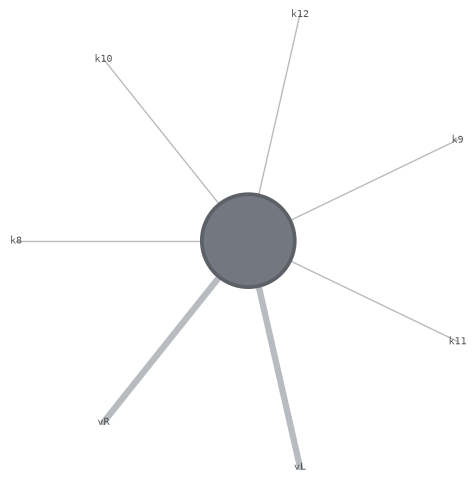

In [70]:
psi_s.draw()

In [71]:
num_spin_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
])

num_ferm_symmetry_sites = len([
    i for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
])

sym_spin_basis = spin_basis_1d(num_spin_symmetry_sites, pauli=-1)
sym_fermion_basis = spinless_fermion_basis_1d(num_ferm_symmetry_sites)
sym_basis = tensor_basis(sym_spin_basis, sym_fermion_basis)

In [72]:
psi_s.ind_size('vR')

23

In [73]:
psi_s.ind_size('vL')

23

In [74]:
domains_dict['symmetry_sites']

[8, 9, 10, 11, 12]

Quite slow...

In [75]:
"""
fixed_virtual_indices_rho_s = list()

even_sym_inds = [
    i for i in domains_dict['symmetry_sites']
    if i%2 == 0
]

odd_sym_inds = [
    i for i in domains_dict['symmetry_sites']
    if i%2 == 1
]

even_odd_sym_inds = even_sym_inds + odd_sym_inds

sym_inds = [f'k{i}' for i in even_odd_sym_inds]

for iL in tqdm(range(psi_s.ind_size('vL'))):
    fixed_virtual_indices_rho_s.append(list())
    for iR in range(psi_s.ind_size('vR')):
        sub_psi_s = psi_s.isel({'vL': iL, 'vR': iR})
        
        quspin_psi_s = (
            sub_psi_s
            .transpose(*sym_inds)
            .data
            .reshape(-1)[::-1]
        )

        rho_s = get_fermionic_rho_from_psi_s(
            quspin_psi_s,
            len(even_sym_inds),
            len(odd_sym_inds)
        )
        # I forgot to save rho_s, ugh.
"""

"\nfixed_virtual_indices_rho_s = list()\n\neven_sym_inds = [\n    i for i in domains_dict['symmetry_sites']\n    if i%2 == 0\n]\n\nodd_sym_inds = [\n    i for i in domains_dict['symmetry_sites']\n    if i%2 == 1\n]\n\neven_odd_sym_inds = even_sym_inds + odd_sym_inds\n\nsym_inds = [f'k{i}' for i in even_odd_sym_inds]\n\nfor iL in tqdm(range(psi_s.ind_size('vL'))):\n    fixed_virtual_indices_rho_s.append(list())\n    for iR in range(psi_s.ind_size('vR')):\n        sub_psi_s = psi_s.isel({'vL': iL, 'vR': iR})\n\n        quspin_psi_s = (\n            sub_psi_s\n            .transpose(*sym_inds)\n            .data\n            .reshape(-1)[::-1]\n        )\n\n        rho_s = get_fermionic_rho_from_psi_s(\n            quspin_psi_s,\n            len(even_sym_inds),\n            len(odd_sym_inds)\n        )\n        # I forgot to save rho_s, ugh.\n"

## Speed up functions

In [76]:
spin_change_of_basis_matrix = 0.5*np.array([
    [1, 1, 0, 0],
    [1, -1, 0, 0],
    [0, 0, 1, 1j],
    [0, 0, 1, -1j]
])

ferm_change_of_basis_matrix = np.array([
    [1, -1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

In [77]:
simple_spin_ops = 'Izxy'
simple_ferm_ops = 'In+-'

In [78]:
def get_fermionic_rho_fast(quspin_psi, domains_dict, verbose=False):
    # Output rho has indices k0, b0, k1, b1, etc...
    L = domains_dict['num_system_sites']//2

    spin_basis = spin_basis_1d(L, pauli=-1)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    sym_sites = domains_dict['symmetry_sites']
    num_symmetry_sites = len(sym_sites)

    spin_symmetry_sites = [
        i//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
    ]
    
    ferm_symmetry_sites = [
        (i-1)//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 1)
    ]

    num_spin_sym_sites = len(spin_symmetry_sites)
    num_ferm_sym_sites = len(ferm_symmetry_sites)
    num_symmetry_sites = len(sym_sites)

    spin_ops_iter = product(simple_spin_ops, repeat=num_spin_sym_sites)
    spin_indices_iter = product(
        range(len(simple_spin_ops)),
        repeat=num_spin_sym_sites
    )
    spin_iter = zip(spin_indices_iter, spin_ops_iter)

    ferm_ops_iter = product(simple_ferm_ops, repeat=num_ferm_sym_sites)
    ferm_indices_iter = product(
        range(len(simple_ferm_ops)),
        repeat=num_ferm_sym_sites
    )
    ferm_iter = zip(ferm_indices_iter, ferm_ops_iter)

    index = spin_symmetry_sites + ferm_symmetry_sites

    data = np.zeros((4,)*(num_symmetry_sites), dtype=complex)

    if verbose:
        spin_ferm_iter = tqdm(list(product(spin_iter, ferm_iter)))
    else:
        spin_ferm_iter = list(product(spin_iter, ferm_iter))

    for spin_pair, ferm_pair in spin_ferm_iter:
        spin_index, spin_op = spin_pair
        ferm_index, ferm_op = ferm_pair

        spin_op_string = ''.join(spin_op)
        ferm_op_string = ''.join(ferm_op)

        terms = [[f'{spin_op_string}|{ferm_op_string}', [[1, *index]]]]

        op = hamiltonian(
            terms,
            [],
            basis=basis,
            check_herm=False,
            check_symm=False,
        )

        exp = op.expt_value(quspin_psi)

        data[*spin_index, *ferm_index] = exp

    for i in range(num_spin_sym_sites):
        data = np.tensordot(
            spin_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    for i in range(num_spin_sym_sites, num_symmetry_sites):
        data = np.tensordot(
            ferm_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    data = data.reshape((2,)*(2*num_symmetry_sites))

    return data

In [79]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12]
}

In [80]:
psi = triv_groundstates[0]

In [81]:
L = domains_dict['num_system_sites']//2

spin_basis = spin_basis_1d(L, pauli=-1)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

sym_sites = domains_dict['symmetry_sites']
num_symmetry_sites = len(sym_sites)

spin_symmetry_sites = [
    i//2 for i in domains_dict['symmetry_sites']
    if (i%2 == 0)
]

ferm_symmetry_sites = [
    (i-1)//2 for i in domains_dict['symmetry_sites']
    if (i%2 == 1)
]

num_spin_sym_sites = len(spin_symmetry_sites)
num_ferm_sym_sites = len(ferm_symmetry_sites)
num_symmetry_sites = len(sym_sites)

In [82]:
print(
    num_spin_sym_sites,
    num_ferm_symmetry_sites
)

3 2


In [83]:
rho_fast = get_fermionic_rho_fast(psi, domains_dict, verbose=True)

  0%|                                                                                                                                                                                   | 0/1024 [00:00<?, ?it/s]/tmp/ipykernel_4133/2299234239.py:58: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [00:41<00:00, 24.59it/s]


In [84]:
rho_fast.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [85]:
rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [86]:
num_symmetry_sites = len(domains_dict['symmetry_sites'])

In [87]:
rho_fast_transposed = rho_fast.transpose(*(
    [2*i for i in range(num_symmetry_sites)]
    +[2*i+1 for i in range(num_symmetry_sites)]
))

In [88]:
np.trace(rho_fast_transposed.reshape(32, 32,))

np.complex128(1.0000000000000024-1.2080939767640195e-14j)

Still have trace 1, nice.

In [89]:
np.linalg.norm(rho_fast_transposed - rho)

np.float64(0.09636078363728363)

In [90]:
np.max(np.abs(rho_fast_transposed - rho))

np.float64(0.05503963704525458)

In [91]:
np.argmax(np.abs(rho_fast_transposed - rho))

np.int64(10)

In [92]:
rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [93]:
np.unravel_index(10, (2,)*10)

(np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0))

In [94]:
test_index = [0, 0, 0, 0, 0, 0, 1, 0, 1, 0]

In [95]:
rho[*test_index]

np.complex128(0.05503963704525458+2.433056136593257e-16j)

In [96]:
rho_fast_transposed[*test_index]

np.complex128(4.316259113775572e-32+0j)

In [97]:
np.argwhere(np.abs(rho_fast_transposed - rho) > 0.001)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 1, 0, 1],
       [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 1, 0, 1, 0],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]])

In [98]:
index=(0,)*10

In [99]:
rho[*index]

np.complex128(0.9875589382429709+0j)

In [100]:
rho_fast_transposed[*index]

np.complex128(1.0000000000000018+0j)

In [101]:
indices = product([0,1], repeat=5)

In [102]:
[
    rho_fast_transposed[*i, *i]
    for i in product([0,1], repeat=5)
]

[np.complex128(1.0000000000000018+0j),
 np.complex128(-1.7095427026752215e-16-1.9116981297921655e-16j),
 np.complex128(4.9224658404702246e-17+1.1744728600435518e-16j),
 np.complex128(2.2221601125384353e-17-1.945115566637079e-17j),
 np.complex128(-1.8044445020097951e-16-2.6194771551793208e-17j),
 np.complex128(-1.8061195951057356e-17-8.366666824505883e-18j),
 np.complex128(3.7318730431052743e-17-2.3750521576740193e-17j),
 np.complex128(6.195980663610463e-18+8.926452450582522e-18j),
 np.complex128(6.4790619328647e-15-6.758678544298416e-15j),
 np.complex128(-2.4269033164792304e-30-8.45341452836686e-33j),
 np.complex128(1.1292126571941179e-30+4.267827071789885e-31j),
 np.complex128(1.7258828285319623e-32-2.809266114246801e-31j),
 np.complex128(-1.3969134323708153e-30+9.75783629441555e-31j),
 np.complex128(-1.7251625317530605e-31+7.824197787884013e-32j),
 np.complex128(7.282588380817091e-32-4.079311067076201e-31j),
 np.complex128(1.016286106603065e-31+1.7100620667886958e-32j),
 np.complex12

In [103]:
[
    rho[*i, *i]
    for i in product([0,1], repeat=5)
]

[np.complex128(0.9875589382429709+0j),
 np.complex128(0.0007649738536632212+0j),
 np.complex128(0.003134931104534943+0j),
 np.complex128(2.4283516002310626e-06+0j),
 np.complex128(4.737566138131787e-06+0j),
 np.complex128(0.0007631881513122294+0j),
 np.complex128(1.503904513551606e-08+0j),
 np.complex128(2.4226830232714296e-06+0j),
 np.complex128(0.003134931104534951+0j),
 np.complex128(2.4283516002310804e-06+0j),
 np.complex128(0.0030769910699295555+0j),
 np.complex128(2.383470621651323e-06+0j),
 np.complex128(1.5039045135519386e-08+0j),
 np.complex128(2.4226830232714423e-06+0j),
 np.complex128(1.4761092361906507e-08+0j),
 np.complex128(2.3779068117613174e-06+0j),
 np.complex128(0.0007649740035198763+0j),
 np.complex128(2.9517139304834716e-06+0j),
 np.complex128(2.4283520759396715e-06+0j),
 np.complex128(9.369992467309266e-09+0j),
 np.complex128(0.0007631881515420157+0j),
 np.complex128(1.184159568581766e-06+0j),
 np.complex128(2.4226830240008868e-06+0j),
 np.complex128(3.759024925524

So the fast method is more accurate!

In [112]:
def get_fermionic_rho_from_psi_s_fast(quimb_psi_s, domains_dict, verbose=False):
    # Output rho has indices k0, b0, k1, b1, etc...
    even_sym_inds = [
        i for i in domains_dict['symmetry_sites']
        if i%2 == 0
    ]

    odd_sym_inds = [
        i for i in domains_dict['symmetry_sites']
        if i%2 == 1
    ]

    even_odd_sym_inds = even_sym_inds + odd_sym_inds
    
    sym_inds = [f'k{i}' for i in even_odd_sym_inds]

    num_spin_sites = len(even_sym_inds)
    num_ferm_sites = len(odd_sym_inds)
    num_sites = num_spin_sites + num_ferm_sites

    spin_basis = spin_basis_1d(num_spin_sites, pauli=-1)
    ferm_basis = spinless_fermion_basis_1d(num_ferm_sites)
    basis = tensor_basis(spin_basis, ferm_basis)

    spin_symmetry_sites = list(range(num_spin_sites))
    ferm_symmetry_sites = list(range(num_ferm_sites))

    spin_ops_iter = product(simple_spin_ops, repeat=num_spin_sym_sites)
    spin_indices_iter = product(
        range(len(simple_spin_ops)),
        repeat=num_spin_sym_sites
    )
    spin_iter = zip(spin_indices_iter, spin_ops_iter)

    ferm_ops_iter = product(simple_ferm_ops, repeat=num_ferm_sym_sites)
    ferm_indices_iter = product(
        range(len(simple_ferm_ops)),
        repeat=num_ferm_sym_sites
    )
    ferm_iter = zip(ferm_indices_iter, ferm_ops_iter)

    index = spin_symmetry_sites + ferm_symmetry_sites

    left_virtual_dim = quimb_psi_s.ind_size('vL')
    right_virtual_dim = quimb_psi_s.ind_size('vR')

    data = np.zeros((4,)*(num_symmetry_sites), dtype=complex)

    spin_ferm_iter = list(product(
        spin_iter,
        ferm_iter
    ))

    if verbose:
        spin_ferm_iter = tqdm(spin_ferm_iter)

    # A nested loop would reduce some redundcancy and speed this up a bit I think.
    for spin_pair, ferm_pair in spin_ferm_iter:
        spin_index, spin_op = spin_pair
        ferm_index, ferm_op = ferm_pair

        spin_op_string = ''.join(spin_op)
        ferm_op_string = ''.join(ferm_op)

        terms = [[f'{spin_op_string}|{ferm_op_string}', [[1, *index]]]]

        op = hamiltonian(
            terms,
            [],
            basis=basis,
            check_herm=False,
            check_symm=False,
        )

        for iVl, iVr in product(range(left_virtual_dim), range(right_virtual_dim)):
            sub_psi_s = quimb_psi_s.isel({'vL': iVl, 'vR': iVr})

            quspin_psi_s = (
                sub_psi_s
                .transpose(*sym_inds)
                .data
                .reshape(-1)[::-1]
            )

            exp = op.expt_value(quspin_psi_s)
    
            data[*spin_index, *ferm_index] += exp


    for i in range(num_spin_sym_sites):
        data = np.tensordot(
            spin_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    for i in range(num_spin_sym_sites, num_symmetry_sites):
        data = np.tensordot(
            ferm_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    data = data.reshape((2,)*(2*num_symmetry_sites))

    return data

In [110]:
psi_s

Tensor(shape=(2, 2, 2, 2, 2, 23, 23), inds=('k8', 'k10', 'k12', 'k9', 'k11', 'vL', 'vR'), tags=oset([]))

In [113]:
rho_s = get_fermionic_rho_from_psi_s_fast(
    psi_s,
    domains_dict,
    verbose=True
)

  0%|                                                                                                                                                                                   | 0/1024 [00:00<?, ?it/s]/tmp/ipykernel_4133/1932661671.py:67: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [00:16<00:00, 63.11it/s]


In [114]:
rho_s_transposed = rho_s.transpose(*(
    [2*i for i in range(num_symmetry_sites)]
    +[2*i+1 for i in range(num_symmetry_sites)]
))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [115]:
np.trace(rho_s_transposed.reshape(32, 32,))

np.complex128(0.9830201132754305+1.5732838467088124e-15j)

In [116]:
np.linalg.norm(rho_s_transposed - rho_fast_transposed)

np.float64(0.09636078363728384)

In [118]:
np.max(np.abs(rho_s_transposed - rho_fast_transposed))

np.float64(0.05503963704525458)

So there is a small difference here... why?

In [117]:
np.linalg.norm(rho_s_transposed - rho)

np.float64(0.13481469920805175)

Hm...

In [119]:
import quimb

# Conclusions
Good to understand how to extract $\rho$, but this appraoch is more difficult than I appreciated.

Need to keep track of fermion parity at virtual indices, important for commuting/anti-commuting expectations etc.